[[Model]]
    Model(sellmeier)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 80
    # data points      = 15
    # variables        = 6
    chi-square         = 3.4469e-05
    reduced chi-square = 3.8299e-06
    Akaike info crit   = -182.752414
    Bayesian info crit = -178.504113
    R-squared          = 0.99440323
[[Variables]]
    B1:  1.00219845 +/- 1971124.26 (196680034.74%) (init = 1.039612)
    B2:  0.20034231 +/- 1971121.81 (983876959.13%) (init = 0.2317923)
    B3:  0.94199434 +/- 18.2111513 (1933.25%) (init = 1.010469)
    C1:  0.01379320 +/- 34.2727400 (248475.62%) (init = 0.00600069)
    C2:  0.01379301 +/- 171.119107 (1240621.85%) (init = 0.02001791)
    C3:  130.000000 +/- 397.484750 (305.76%) (init = 103.5607)
[[Correlations]] (unreported correlations are < 0.100)
    C(B1, B2) = -1.0000
    C(B3, C3) = +0.9999
    C(C1, C2) = -0.9875
    C(B3, C1) = -0.5791
    C(C1, C3) = -0.5734
    C(B3, C2) = +0.5677
    C(C2, C3) = +0.5624


C:\Users\Hp\AppData\Local\Temp\ipykernel_11492\925612916.py:70: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\Hp\AppData\Local\Temp\ipykernel_11492\925612916.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


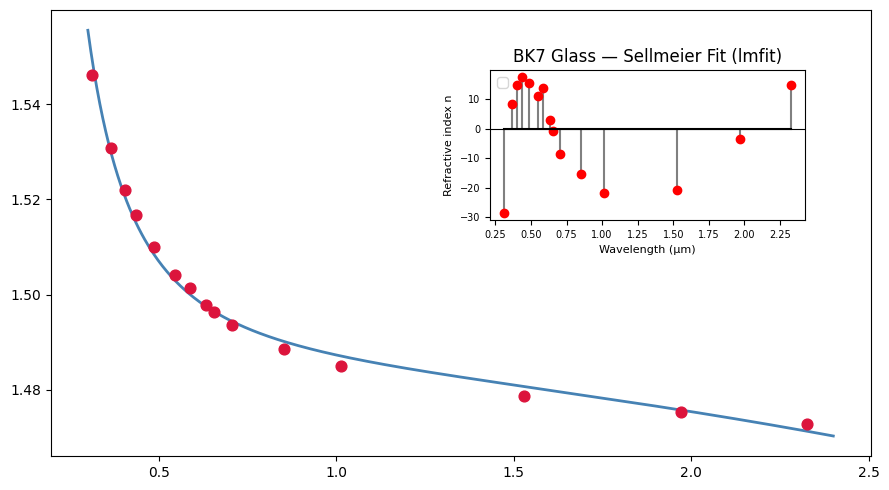

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from lmfit import Model, Parameters

# ── Real BK7 refractive index data (Schott datasheet) ──────────────────
# wavelength in micrometers (μm)
wavelength = np.array([
    0.3125, 0.3650, 0.4047, 0.4358, 0.4861,
    0.5461, 0.5876, 0.6328, 0.6563, 0.7065,
    0.8521, 1.0140, 1.5296, 1.9701, 2.3254
])

n_measured = np.array([
    1.5462, 1.5307, 1.5220, 1.5168, 1.5100,
    1.5040, 1.5014, 1.4978, 1.4963, 1.4935,
    1.4886, 1.4849, 1.4786, 1.4754, 1.4728
])

# ── Sellmeier Equation ──────────────────────────────────────────────────
# n²(λ) = 1 + B1λ²/(λ²-C1) + B2λ²/(λ²-C2) + B3λ²/(λ²-C3)

def sellmeier(lam, B1, B2, B3, C1, C2, C3):
    lam2 = lam**2
    n_sq = 1 + (B1*lam2)/(lam2 - C1) \
             + (B2*lam2)/(lam2 - C2) \
             + (B3*lam2)/(lam2 - C3)
    return np.sqrt(n_sq)

# ── lmfit setup ────────────────────────────────────────────────────────
model = Model(sellmeier)

params = Parameters()
# Initial guesses (Schott BK7 known values — দেখো fit কতটা কাছে যায়!)
params.add('B1', value=1.03961212, min=0.8,  max=1.3)
params.add('B2', value=0.23179234, min=0.1,  max=0.5)
params.add('B3', value=1.01046945, min=0.7,  max=1.3)
params.add('C1', value=0.00600069, min=0.001, max=0.02)
params.add('C2', value=0.02001791, min=0.01,  max=0.05)
params.add('C3', value=103.560653, min=80.0,  max=130.0)

# ── Fit! ───────────────────────────────────────────────────────────────
result = model.fit(n_measured, params, lam=wavelength)

print(result.fit_report())

# ── Plot ───────────────────────────────────────────────────────────────
lam_fine = np.linspace(0.3, 2.4, 500)
n_fit    = result.eval(lam=lam_fine)

plt.figure(figsize=(9, 5))
plt.scatter(wavelength, n_measured, color='crimson', zorder=5,
            s=60, label='Measured data (Schott)')
plt.plot(lam_fine, n_fit, color='steelblue', lw=2,
         label='Sellmeier fit (lmfit)')

# Residuals inset
ax_res = plt.axes([0.55, 0.55, 0.35, 0.30])
residuals = n_measured - result.eval(lam=wavelength)
ax_res.stem(wavelength, residuals * 1e4, markerfmt='ro', linefmt='gray',
            basefmt='k-')
ax_res.axhline(0, color='k', lw=0.8)
ax_res.set_xlabel('λ (μm)', fontsize=8)
ax_res.set_ylabel('Residual ×10⁴', fontsize=8)
ax_res.set_title('Residuals', fontsize=9)
ax_res.tick_params(labelsize=7)

plt.xlabel('Wavelength (μm)')
plt.ylabel('Refractive index n')
plt.title('BK7 Glass — Sellmeier Fit (lmfit)')
plt.legend()
plt.tight_layout()
plt.show()

[[Model]]
    Model(sellmeier2)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 21
    # data points      = 15
    # variables        = 3
    chi-square         = 3.4737e-05
    reduced chi-square = 2.8948e-06
    Akaike info crit   = -188.636294
    Bayesian info crit = -186.512144
    R-squared          = 0.99435974
[[Variables]]
    B1:  1.20247265 +/- 0.00276045 (0.23%) (init = 1.04)
    B2:  0.74142203 +/- 0.10038047 (13.54%) (init = 0.23)
    C1:  0.01379923 +/- 3.8027e-04 (2.76%) (init = 0.006)
    C2:  103.56 (fixed)
[[Correlations]] (unreported correlations are < 0.100)
    C(B1, C1) = -0.8368
    C(B1, B2) = +0.7250
    C(B2, C1) = -0.5667


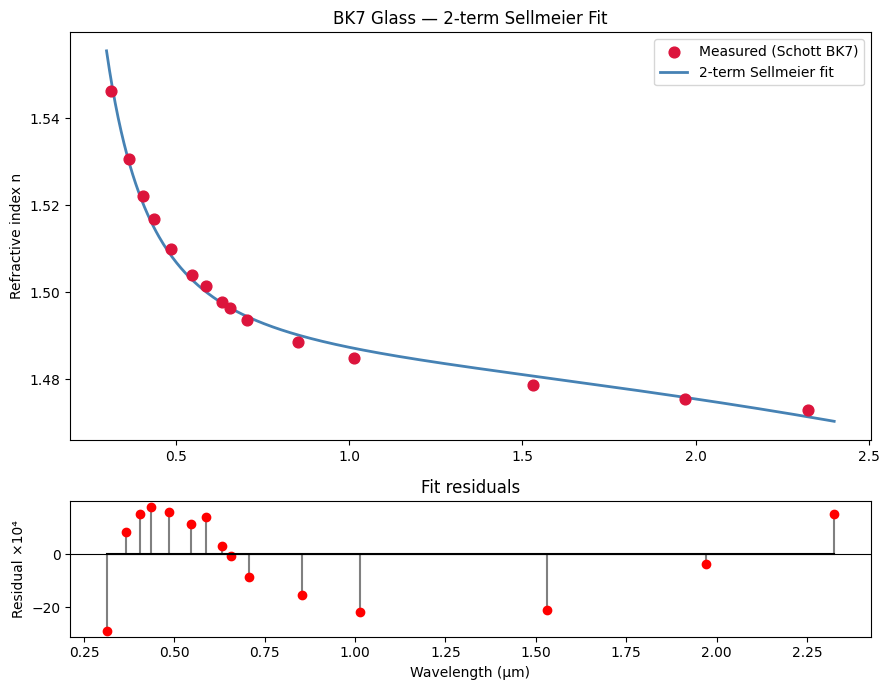

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from lmfit import Model, Parameters

wavelength = np.array([
    0.3125, 0.3650, 0.4047, 0.4358, 0.4861,
    0.5461, 0.5876, 0.6328, 0.6563, 0.7065,
    0.8521, 1.0140, 1.5296, 1.9701, 2.3254
])

n_measured = np.array([
    1.5462, 1.5307, 1.5220, 1.5168, 1.5100,
    1.5040, 1.5014, 1.4978, 1.4963, 1.4935,
    1.4886, 1.4849, 1.4786, 1.4754, 1.4728
])

# 2-term Sellmeier
def sellmeier2(lam, B1, B2, C1, C2):
    lam2 = lam**2
    n_sq = 1 + (B1*lam2)/(lam2 - C1) \
             + (B2*lam2)/(lam2 - C2)
    return np.sqrt(n_sq)

model = Model(sellmeier2)

params = Parameters()
params.add('B1', value=1.04,  min=0.5,  max=2.0)
params.add('B2', value=0.23,  min=0.0,  max=1.0)
params.add('C1', value=0.006, min=1e-4, max=0.05)
params.add('C2', value=103.56, vary=False)

result = model.fit(n_measured, params, lam=wavelength)
print(result.fit_report())

# Plot
lam_fine = np.linspace(0.3, 2.4, 500)
n_fit = result.eval(lam=lam_fine)
n_eval = result.eval(lam=wavelength)
residuals = (n_measured - n_eval) * 1e4

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7),
                                gridspec_kw={'height_ratios': [3, 1]})

ax1.scatter(wavelength, n_measured, color='crimson', zorder=5,
            s=60, label='Measured (Schott BK7)')
ax1.plot(lam_fine, n_fit, color='steelblue', lw=2, label='2-term Sellmeier fit')
ax1.set_ylabel('Refractive index n')
ax1.set_title('BK7 Glass — 2-term Sellmeier Fit')
ax1.legend()

ax2.stem(wavelength, residuals, markerfmt='ro',
         linefmt='gray', basefmt='k-')
ax2.axhline(0, color='k', lw=0.8)
ax2.set_xlabel('Wavelength (μm)')
ax2.set_ylabel('Residual ×10⁴')
ax2.set_title('Fit residuals')

plt.tight_layout()
plt.show()

[[Model]]
    Model(cauchy)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 13
    # data points      = 15
    # variables        = 2
    chi-square         = 1.1650e-04
    reduced chi-square = 8.9619e-06
    Akaike info crit   = -172.484476
    Bayesian info crit = -171.068375
    R-squared          = 0.98108318
[[Variables]]
    A:  1.47760840 +/- 0.00119483 (0.08%) (init = 1.5)
    B:  0.00714884 +/- 2.7532e-04 (3.85%) (init = 0.005)
[[Correlations]] (unreported correlations are < 0.100)
    C(A, B) = -0.7626


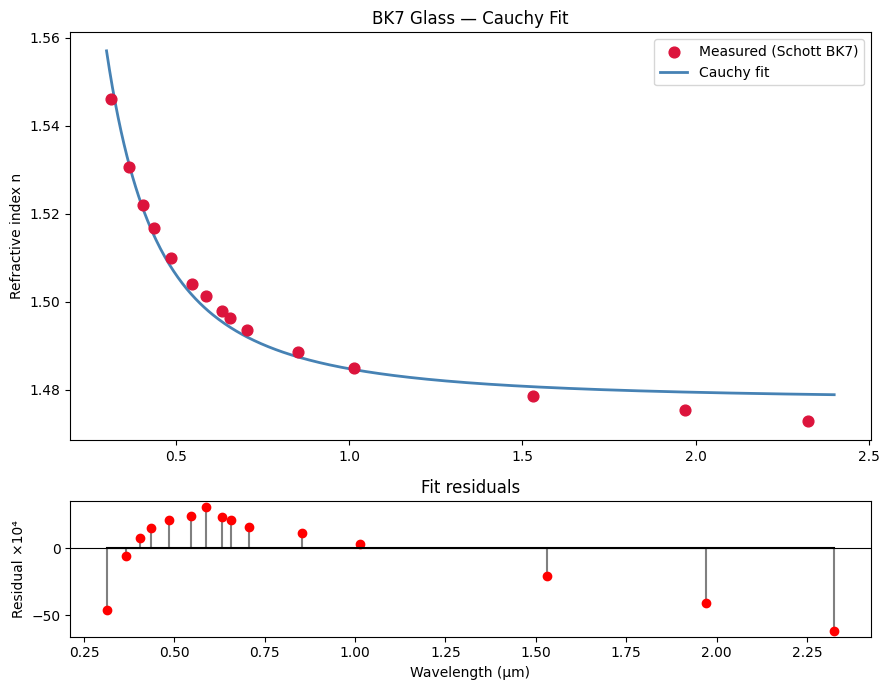

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from lmfit import Model, Parameters

wavelength = np.array([
    0.3125, 0.3650, 0.4047, 0.4358, 0.4861,
    0.5461, 0.5876, 0.6328, 0.6563, 0.7065,
    0.8521, 1.0140, 1.5296, 1.9701, 2.3254
])

n_measured = np.array([
    1.5462, 1.5307, 1.5220, 1.5168, 1.5100,
    1.5040, 1.5014, 1.4978, 1.4963, 1.4935,
    1.4886, 1.4849, 1.4786, 1.4754, 1.4728
])

# Cauchy equation — simple!
def cauchy(lam, A, B):
    return A + B / lam**2

model = Model(cauchy)
params = Parameters()
params.add('A', value=1.5,   min=1.0, max=2.0)
params.add('B', value=0.005, min=0.0, max=0.1)

result = model.fit(n_measured, params, lam=wavelength)
print(result.fit_report())

lam_fine = np.linspace(0.3, 2.4, 500)
n_fit = result.eval(lam=lam_fine)
residuals = (n_measured - result.eval(lam=wavelength)) * 1e4

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7),
                                gridspec_kw={'height_ratios': [3, 1]})

ax1.scatter(wavelength, n_measured, color='crimson',
            zorder=5, s=60, label='Measured (Schott BK7)')
ax1.plot(lam_fine, n_fit, color='steelblue',
         lw=2, label='Cauchy fit')
ax1.set_ylabel('Refractive index n')
ax1.set_title('BK7 Glass — Cauchy Fit')
ax1.legend()

ax2.stem(wavelength, residuals, markerfmt='ro',
         linefmt='gray', basefmt='k-')
ax2.axhline(0, color='k', lw=0.8)
ax2.set_xlabel('Wavelength (μm)')
ax2.set_ylabel('Residual ×10⁴')
ax2.set_title('Fit residuals')

plt.tight_layout()
plt.show()